# Explorer les relations

**Objectif d'apprentissage :**
- Apprendre à filtrer des observations
- Apprendre à comparer des relations
- Apprendre à synthétiser des relations

### Filtrer les observations (lignes)

Généralement, les données c'est "messy", sale/désordonné. La plupart du temps, vous avez besoin de filtrer certaines observations (lignes) dans votre jeu de données.
- Vous vous intéressez à certains aspects particuliers de votre jeu de données (ex : les jeunes électeurs).
- L'information est non pertinente et vous devez supprimer certaines données pour éviter de tirer de mauvaises conclusions (ex : les personnes qui refusent de répondre).

Vous avez donc besoin d'un moyen de filtrer les observations dans votre jeu de données.

- Les opérateurs relationnels permettent de sélectionner des observations.
- Il existe aussi des méthodes utiles pour vous aider dans cette tâche.

![](https://pandas.pydata.org/docs/_images/03_subset_rows.svg)

Nous avons vu que les données de l'ANES contiennent des valeurs comme -8, -9, 99, qui peuvent ou non être utiles selon le problème que l'on souhaite traiter.

Comment peut-on les gérer ?

Commençons par cette question pour illustrer :
- Les jeunes électeurs sont-ils plus libéraux ou conservateurs ?


In [1]:
# Charger pandas
import pandas as pd

# Charger des données avec pandas depuis une URL
data_url = "https://raw.githubusercontent.com/datamisc/ts-2024/main/data.csv"
anes_data = pd.read_csv(data_url, compression="gzip", low_memory=False)


In [2]:
# Sélectionner un sous ensemble de  variables et renommer
my_vars = [
    "V241042",  # a l'intention de voter ou non
    "V241043",  # pour qui a l'intention de voter
    "V241458x",  # age
    "V241177",  # autoplacement sur une échelle libéral-conservateur
]

df = anes_data[my_vars]
df.columns = ["vote", "vote_int", "age", "ideologie"]

df.head()

,vote,vote_int,age,ideologie
0,1,2,50,6
1,1,3,41,4
2,1,1,44,2
3,1,2,45,99
4,1,2,80,4


<Axes: xlabel='ideologie'>

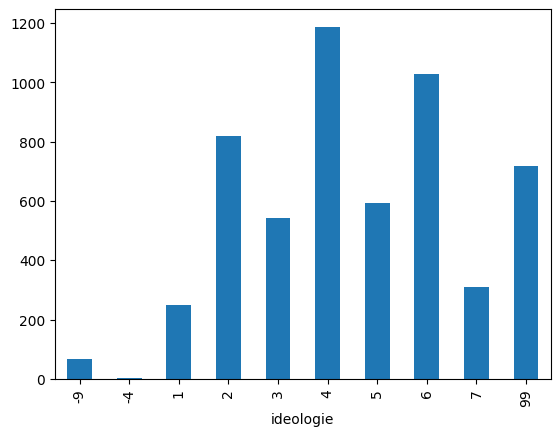

In [ ]:
# Quelle est la répartition par idéologie ?
df.value_counts("ideologie").sort_index().plot(kind="bar")

# nb : .sort_index() permet de trier les barres par ordre alphanumérique de l'index
# (ici, les valeurs de la variable idéologie)
# plutôt que par effectifs

# nb2 : df.value_counts("ideologie") est ici équivalent
# à df["ideologie"].value_counts()
# que l'on avait vu précédemment

<Axes: ylabel='Frequency'>

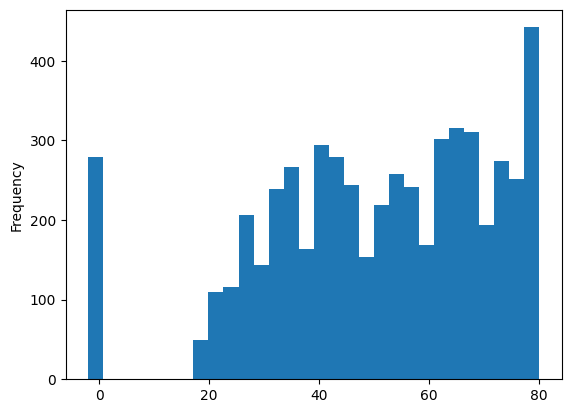

In [5]:
# Quelle est la ditrbution par âge ?
df["age"].plot(kind="hist", bins=30)


In [6]:
df.describe()

,vote,vote_int,age,ideologie
count,5521.000000,5521.000000,5521.000000,5521.000000
mean,0.888064,1.068647,50.363521,16.327477
std,0.807216,1.738679,20.777293,32.063812
min,-9.000000,-9.000000,-2.000000,-9.000000
25%,1.000000,1.000000,36.000000,3.000000
50%,1.000000,1.000000,52.000000,4.000000
75%,1.000000,2.000000,67.000000,6.000000
max,2.000000,6.000000,80.000000,99.000000


On a besoin de faire un peu de nettoyage dans ces variables !

In [8]:
# nettoyer la variable age
mask_age = df["age"] >= 18
mask_age


0        True
1        True
2        True
3        True
4        True
        ...  
5516    False
5517     True
5518    False
5519     True
5520     True
Name: age, Length: 5521, dtype: bool

In [9]:
# L'age à l'air ok désormais, mais on a perdu des observations !
df[mask_age].describe()


,vote,vote_int,age,ideologie
count,5242.000000,5242.000000,5242.000000,5242.000000
mean,0.897177,1.099199,53.150515,16.514880
std,0.796095,1.660363,17.347720,32.264763
min,-9.000000,-9.000000,18.000000,-9.000000
25%,1.000000,1.000000,39.000000,3.000000
50%,1.000000,1.000000,54.000000,4.000000
75%,1.000000,2.000000,68.000000,6.000000
max,2.000000,6.000000,80.000000,99.000000


In [10]:
# Sauvegarder le dataframe avec les données filtrées
df = df[mask_age]

In [11]:
# Netoyons la variable ideologie
mask_ideo = (df["ideologie"] >= 1) & (df["ideologie"] <= 7)
mask_ideo

0        True
1        True
2        True
3       False
4        True
        ...  
5514     True
5515     True
5517     True
5519     True
5520     True
Name: ideologie, Length: 5242, dtype: bool

In [12]:
df = df[mask_ideo]
df.describe()

,vote,vote_int,age,ideologie
count,4490.000000,4490.000000,4490.000000,4490.000000
mean,0.886637,1.190200,53.410245,4.116927
std,0.724657,1.519867,17.265298,1.690302
min,-9.000000,-9.000000,18.000000,1.000000
25%,1.000000,1.000000,39.000000,3.000000
50%,1.000000,1.000000,54.000000,4.000000
75%,1.000000,2.000000,68.000000,6.000000
max,2.000000,6.000000,80.000000,7.000000


<Axes: ylabel='Frequency'>

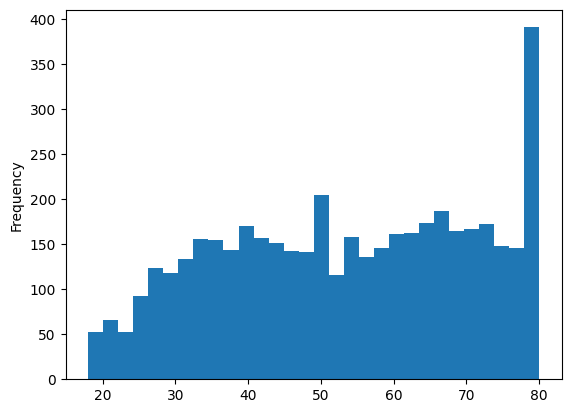

In [13]:
# Comment est distribué l'age désormais ?
df["age"].plot(kind="hist", bins=30)


<Axes: xlabel='ideologie'>

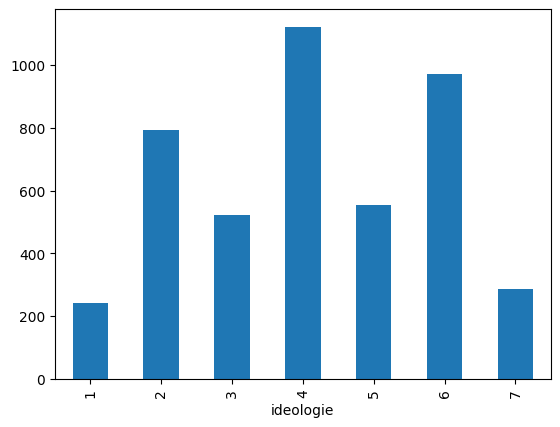

In [14]:
# Ct comment est distribuée l'ideologie maintenant ?
df.value_counts("ideologie").sort_index().plot(kind="bar")

### Hack-Time



In [31]:
# Nettoyer la variable `vote`


In [30]:
# Nettoyer la variable `vote_int`


## Who are young voters?

In [45]:
# Definir les jeunes électeurs
mask = df["age"] <= 80


In [46]:
# Quel groupe est plus libéral ? Quel groupe est plus conservateur ?
print(df[mask]["ideologie"].mean())
print(df[~mask]["ideologie"].mean())


4.116926503340757
nan


In [47]:
# Est-ce qu'on a oublié quelque chose ?


Pourrait-on visualiser cette relation d'une autre manière ?


## Types of Data & Levels of Measurement

We have seen that there are two main types of data: Discrete and Continuous.

- **Discrete** data can only take a finite number of values.
    - eg. The number of political parties in a country.

- **Continuous** data can take an infinite number of values.
    - eg. The age of someone.



### We can further divide each of these data types into four families:

- **Nominal:** Differences of kind. There is no mathematical relationship between the values.
    - eg. Number of political parties.

- **Ordinal:** Differences of degree. There is a mathematical relationships among the values. Symbols like <, ≤, =, ≥, and > have meaning but the distance between two elements is not constant.
    - eg. Levels of education.

- **Interval:** There is a mathematical relationship among the elements and the distance between them is constant but they do not have a meaningful zero value.
    - eg. Liberal-conservative 7 point scale.

- **Ratio:** Similar to the interval variables but they have a meaningful zero value.
    - eg. Age

|          | Continuous | Discrete |
| -:       | :-:        | :-:      |
| Nominal  |            | x        |
| Ordinal  |            | x        |
| Interval | x          | x        |
| Ratio    | x          | x        |


## Continuous & Continuous



<Axes: xlabel='ideologie', ylabel='age'>

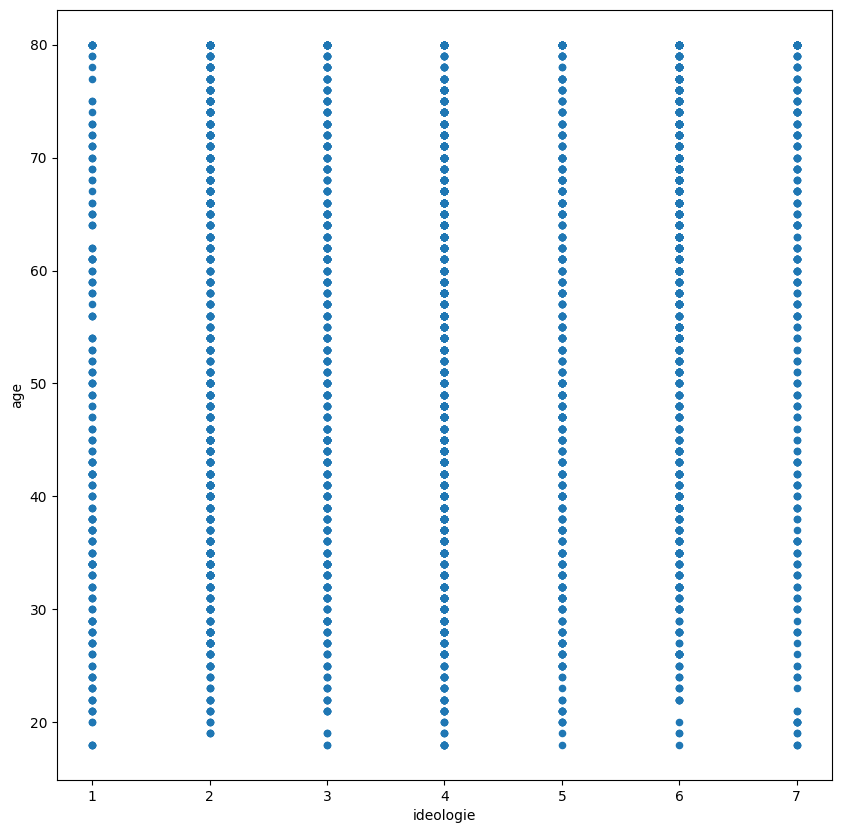

In [70]:
# What is the relationship between Age and Ideology?
df.plot(kind="scatter", x="ideologie", y="age", figsize=(10, 10))


<Axes: xlabel='ideologie', ylabel='age'>

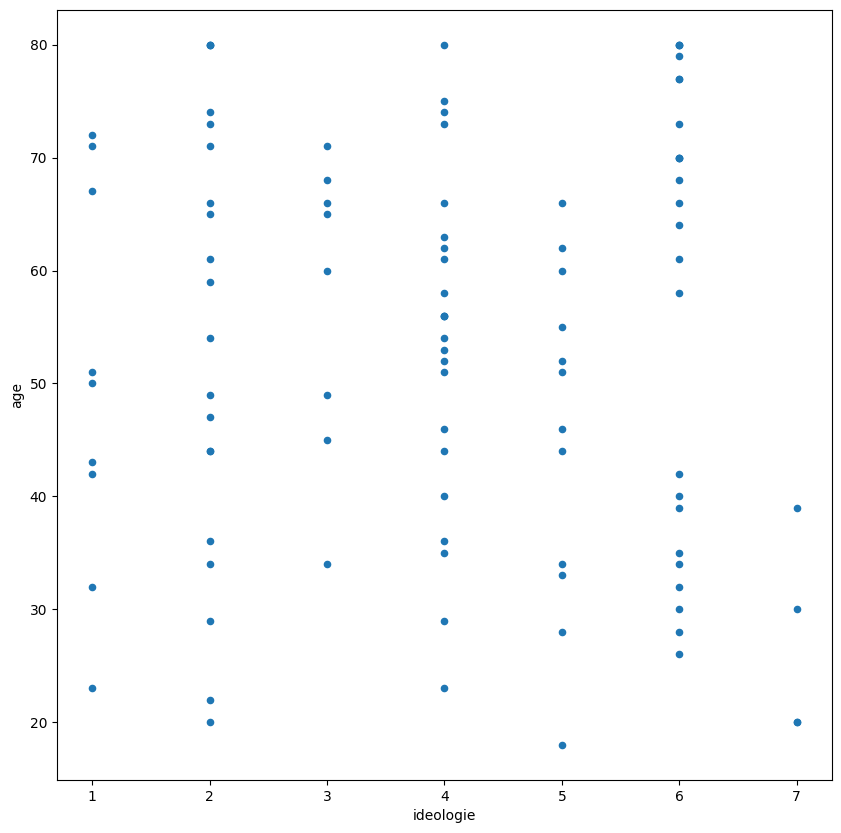

In [51]:
# We can sample some data
df.sample(100).plot(kind="scatter", x="ideologie", y="age", figsize=(10, 10))


<Axes: xlabel='ideologie', ylabel='age'>

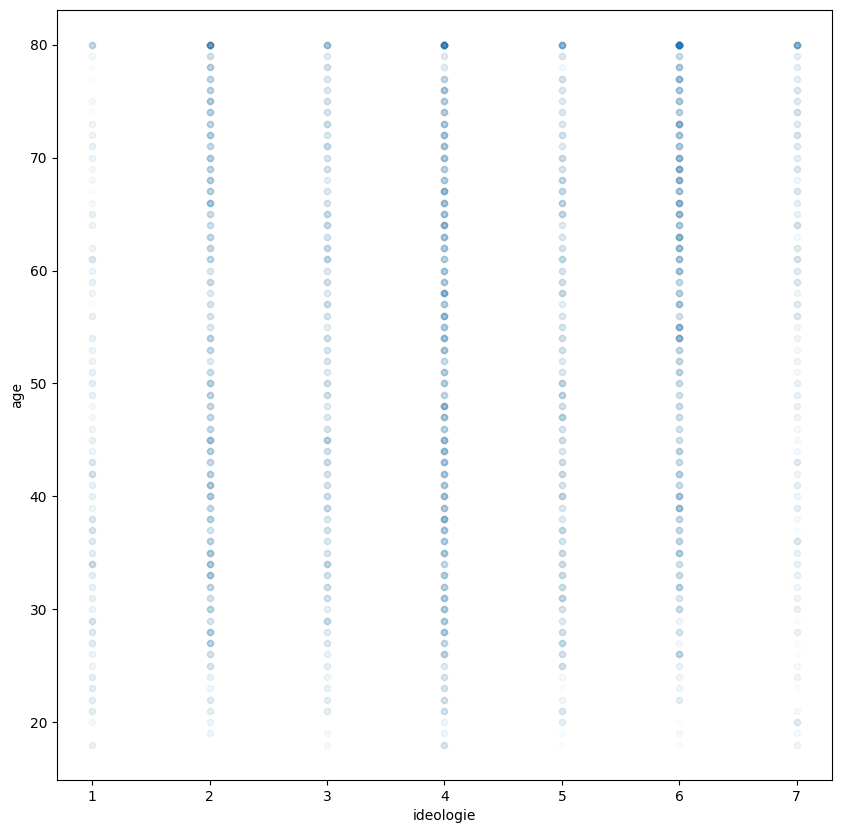

In [52]:
# We can try to add transparency
df.plot(kind="scatter", x="ideologie", y="age", alpha=0.02, figsize=(10, 10))


<Axes: xlabel='ideologie', ylabel='age'>

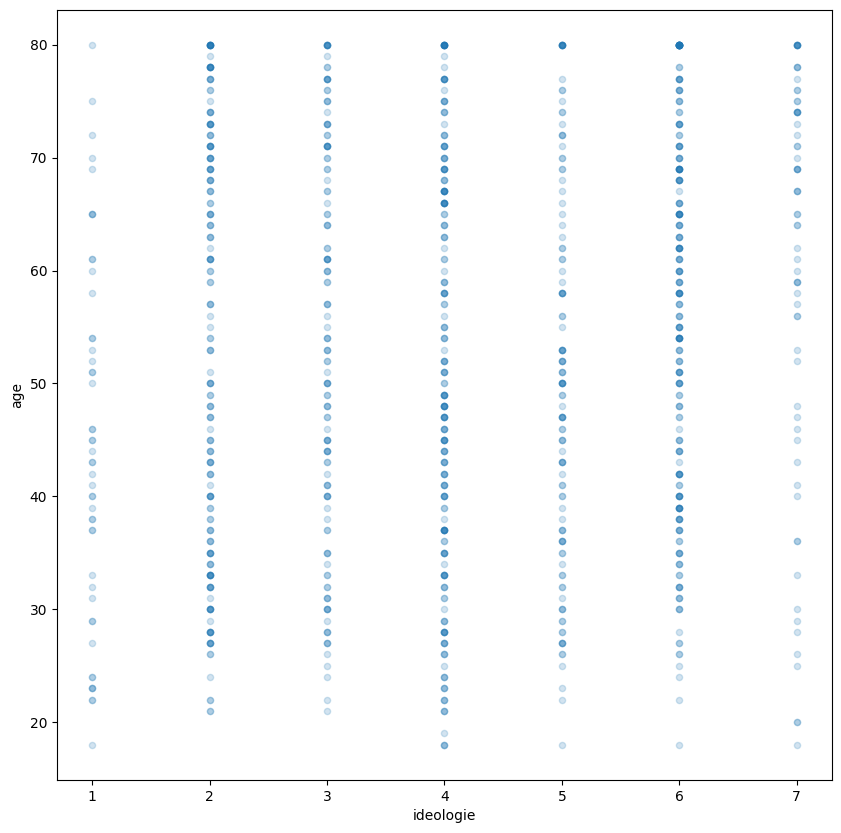

In [ ]:
# We can try to add transparency
df.sample(1000).plot(
    kind="scatter", x="ideologie", y="age", alpha=0.2, figsize=(10, 10)
)


<Axes: xlabel='ideologie', ylabel='age'>

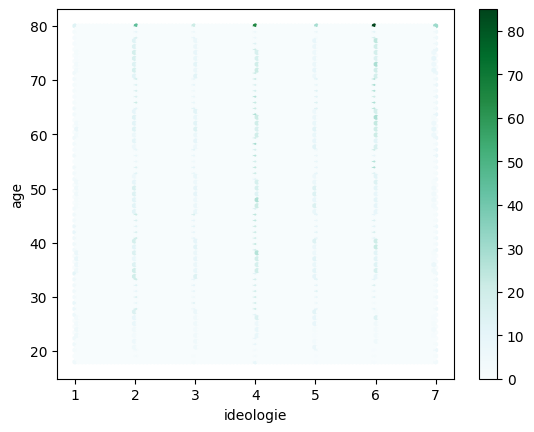

In [54]:
# Using hexbin plots
df.plot(kind="hexbin", x="ideologie", y="age")

<Axes: xlabel='ideologie', ylabel='age'>

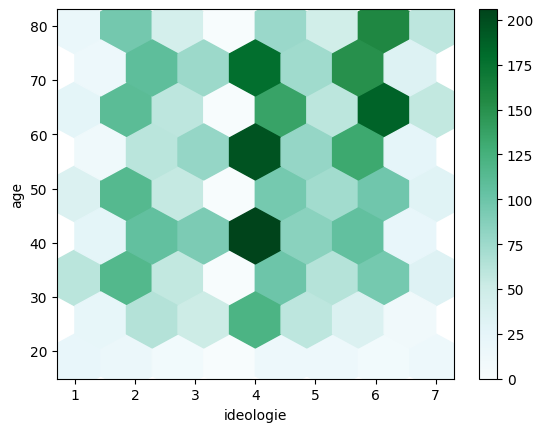

In [55]:
# Increasing the grid size
df.plot(kind="hexbin", x="ideologie", y="age", gridsize=7)


## Discrete & Continuous

![](https://miro.medium.com/max/1400/1*2c21SkzJMf3frPXPAR_gZA.png)



<Axes: title={'center': 'age'}, xlabel='[ideologie]'>

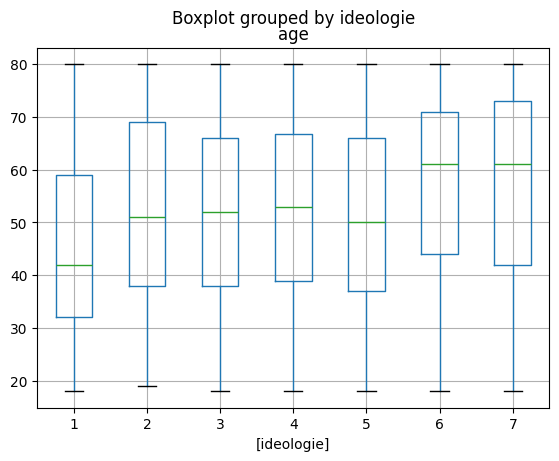

In [57]:
# Is there a relationship between Age and Ideology?
my_vars = ["age", "ideologie"]
df[my_vars].boxplot(by="ideologie")


## Discrète & Discrète 

### Tableaux croisés

On peut utiliser la fonction `pd.crosstab()` pour réaliser des tableaux croisés entre deux variables (ou plus) 

![](https://www.dataindependent.com/wp-content/uploads/2020/08/Screen-Shot-2020-08-17-at-7.43.21-AM-1024x466.png)


In [88]:
# Tableau croisé
pd.crosstab(df["ideologie"], df["vote_int"])


vote_int,-9,-8,-1,1,2,3,4,5,6
ideologie,,,,,,,,,
1,0,0,27,187,9,2,2,10,4
2,0,1,90,672,17,7,2,1,4
3,1,1,40,423,40,9,1,3,3
4,11,8,195,530,263,67,9,11,28
5,7,6,93,117,278,28,3,3,19
6,2,2,114,51,764,22,2,2,12
7,0,0,35,14,236,0,0,0,2


In [89]:
# Similaire à …
df.groupby("ideologie")["vote_int"].value_counts().unstack().fillna(0).astype(int)


vote_int,-9,-8,-1,1,2,3,4,5,6
ideologie,,,,,,,,,
1,0,0,27,187,9,2,2,10,4
2,0,1,90,672,17,7,2,1,4
3,1,1,40,423,40,9,1,3,3
4,11,8,195,530,263,67,9,11,28
5,7,6,93,117,278,28,3,3,19
6,2,2,114,51,764,22,2,2,12
7,0,0,35,14,236,0,0,0,2


In [90]:
# Les valeurs absolues ne sont pas très parlantes
# pourcentage du total :
pd.crosstab(df["ideologie"], df["vote_int"], normalize=True)


vote_int,-9,-8,-1,1,2,3,4,5,6
ideologie,,,,,,,,,
1,0.000000,0.000000,0.006013,0.041648,0.002004,0.000445,0.000445,0.002227,0.000891
2,0.000000,0.000223,0.020045,0.149666,0.003786,0.001559,0.000445,0.000223,0.000891
3,0.000223,0.000223,0.008909,0.094209,0.008909,0.002004,0.000223,0.000668,0.000668
4,0.002450,0.001782,0.043430,0.118040,0.058575,0.014922,0.002004,0.002450,0.006236
5,0.001559,0.001336,0.020713,0.026058,0.061915,0.006236,0.000668,0.000668,0.004232
6,0.000445,0.000445,0.025390,0.011359,0.170156,0.004900,0.000445,0.000445,0.002673
7,0.000000,0.000000,0.007795,0.003118,0.052561,0.000000,0.000000,0.000000,0.000445


<Axes: xlabel='ideologie'>

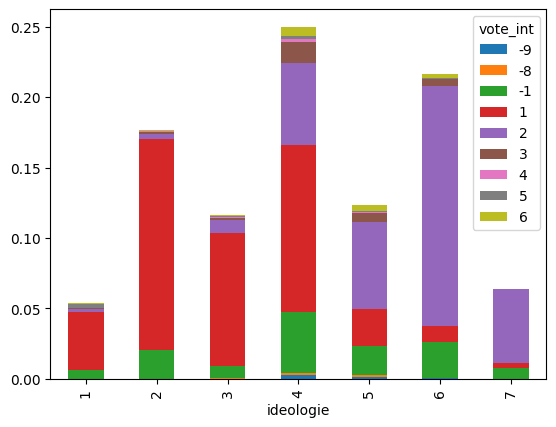

In [94]:
# Les barplots à la rescousse !
pd.crosstab(df["ideologie"], df["vote_int"], normalize=True).plot(
    kind="bar", stacked=True
)


In [ ]:
# Exemple d'un tableau croisé pourcentages en ligne
tab = pd.crosstab(df["ideologie"], df["vote_int"], normalize="index", margins=True)
(tab * 100).round(2)

vote_int,-9,-8,-1,1,2,3,4,5,6
ideologie,,,,,,,,,
1,0.00,0.00,11.20,77.59,3.73,0.83,0.83,4.15,1.66
2,0.00,0.13,11.34,84.63,2.14,0.88,0.25,0.13,0.50
3,0.19,0.19,7.68,81.19,7.68,1.73,0.19,0.58,0.58
4,0.98,0.71,17.38,47.24,23.44,5.97,0.80,0.98,2.50
5,1.26,1.08,16.79,21.12,50.18,5.05,0.54,0.54,3.43
6,0.21,0.21,11.74,5.25,78.68,2.27,0.21,0.21,1.24
7,0.00,0.00,12.20,4.88,82.23,0.00,0.00,0.00,0.70
All,0.47,0.40,13.23,44.41,35.79,3.01,0.42,0.67,1.60


<Axes: xlabel='ideologie'>

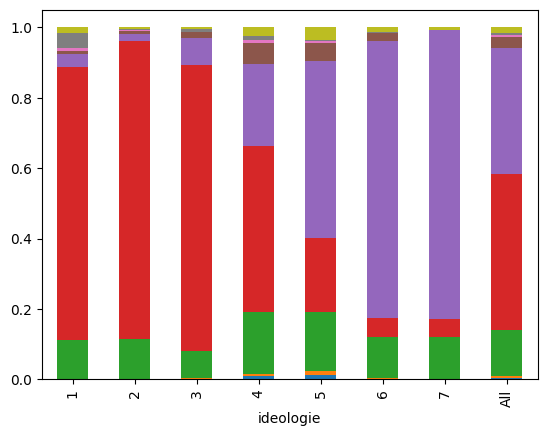

In [100]:
tab.plot(kind="bar", stacked=True, legend=False)